In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint

In [2]:
cwd = Path.cwd()
project_root = cwd.parent
data_path = project_root / "data" / "raw" / "accepted_2007_to_2018q4.csv"/ "accepted_2007_to_2018q4.csv"

In [3]:
data = pd.read_csv(
    filepath_or_buffer=data_path,
    encoding='latin-1',
    sep=",",
    thousands=',',
    na_values=['NA', 'N/A', 'null', 'NULL', '', ' ', 'None'],
    low_memory=False
)

In [4]:
data.shape

(2260701, 151)

In [5]:
data.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), str(38)
memory usage: 2.5 GB


In [8]:
pd.set_option('display.max_rows', 200)

In [9]:
# let's the null percentages of each of the features
null_pct = (data.isna().sum(axis=0)/len(data))*100
null_pct.sort_values(ascending=False)

member_id                                     100.000000
orig_projected_additional_accrued_interest     99.617331
hardship_end_date                              99.517097
hardship_start_date                            99.517097
hardship_type                                  99.517097
hardship_reason                                99.517097
hardship_status                                99.517097
deferral_term                                  99.517097
hardship_last_payment_amount                   99.517097
hardship_payoff_balance_amount                 99.517097
hardship_loan_status                           99.517097
hardship_dpd                                   99.517097
hardship_length                                99.517097
payment_plan_start_date                        99.517097
hardship_amount                                99.517097
settlement_term                                98.485160
debt_settlement_flag_date                      98.485160
settlement_status              

In [11]:
(data["loan_status"].value_counts()/len(data))*100

loan_status
Fully Paid                                             47.629076
Current                                                38.851533
Charged Off                                            11.879457
Late (31-120 days)                                      0.949573
In Grace Period                                         0.373159
Late (16-30 days)                                       0.192374
Does not meet the credit policy. Status:Fully Paid      0.087937
Does not meet the credit policy. Status:Charged Off     0.033662
Default                                                 0.001769
Name: count, dtype: float64

In [12]:
data.dropna(subset=["loan_status"], inplace=True)

In [13]:
u_data = data[(data["loan_status"] != "Current") & (data["loan_status"] != "In Grace Period") & (data["loan_status"] != "Late (16-30 days)")]

In [14]:
u_data["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Charged Off                                             268559
Late (31-120 days)                                       21467
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [15]:
u_data.shape, data.shape

((1369566, 151), (2260668, 151))

In [16]:
u_data = u_data.copy()
u_data["target"] = np.where(
    (u_data["loan_status"] == "Fully Paid") | 
    (u_data["loan_status"] == "Does not meet the credit policy. Status:Fully Paid"), 
    0, 1
)

In [17]:
class_dist = (u_data["target"].value_counts()/len(u_data))*100

In [18]:
class_dist

target
0    78.765025
1    21.234975
Name: count, dtype: float64

In [20]:
u_data.columns.to_list()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [22]:
u_data["loan_amnt"].describe()

count    1.369566e+06
mean     1.444877e+04
std      8.737507e+03
min      5.000000e+02
25%      8.000000e+03
50%      1.200000e+04
75%      2.000000e+04
max      4.000000e+04
Name: loan_amnt, dtype: float64

In [ ]:
null_pct = (u_data.isna().sum(axis=0)/len(u_data))*100
null_pct.sort_values(ascending=False)

In [24]:
null_pct["loan_amnt"]

np.float64(0.0)

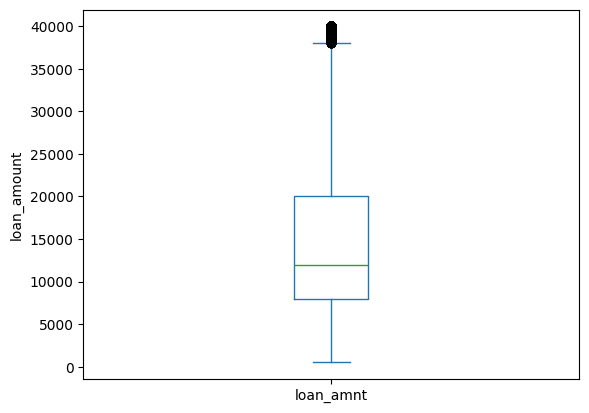

In [26]:
ax = u_data["loan_amnt"].plot.box()
ax.set_ylabel("loan_amount");

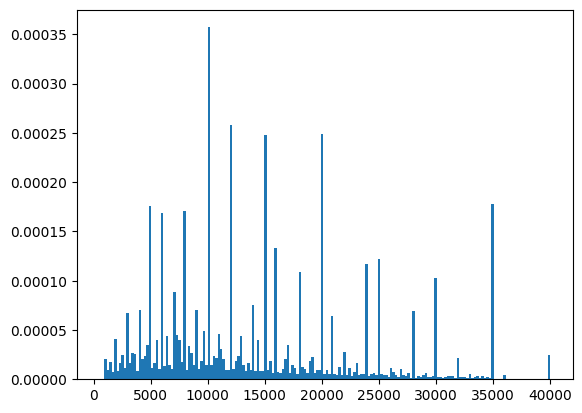

In [30]:
plt.hist(u_data["loan_amnt"], bins='auto', density=True);

In [31]:
ax = pd.cut(u_data["loan_amnt"], 10)
ax.value_counts()

loan_amnt
(8400.0, 12350.0]     297988
(4450.0, 8400.0]      284163
(12350.0, 16300.0]    206965
(16300.0, 20250.0]    166679
(460.5, 4450.0]       117278
(20250.0, 24200.0]     93093
(24200.0, 28150.0]     81249
(32100.0, 36050.0]     63126
(28150.0, 32100.0]     50659
(36050.0, 40000.0]      8366
Name: count, dtype: int64

In [32]:
u_data["loan_amnt"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

0.05     3200.0
0.25     8000.0
0.50    12000.0
0.75    20000.0
0.95    33000.0
Name: loan_amnt, dtype: float64

<Axes: ylabel='Density'>

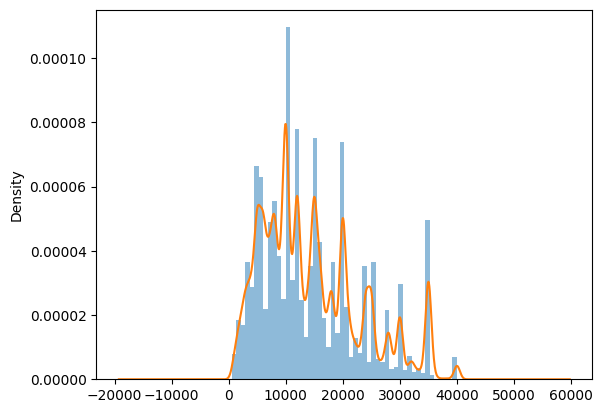

In [38]:
ax = u_data["loan_amnt"].plot.hist(density=True, alpha=0.5, bins=50)
u_data["loan_amnt"].plot.density(ax=ax)

In [40]:
u_data["int_rate"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

0.05     6.54
0.25     9.75
0.50    12.79
0.75    16.02
0.95    22.20
Name: int_rate, dtype: float64

<Axes: >

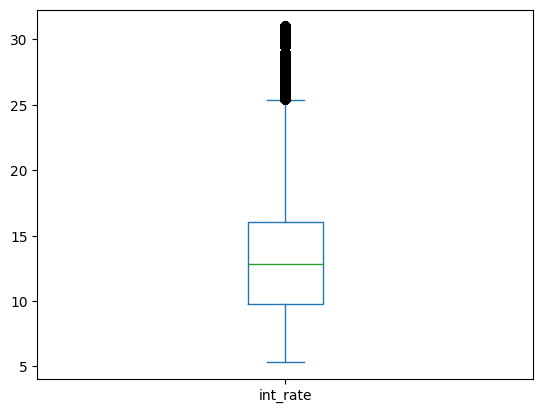

In [43]:
u_data["int_rate"].plot.box()

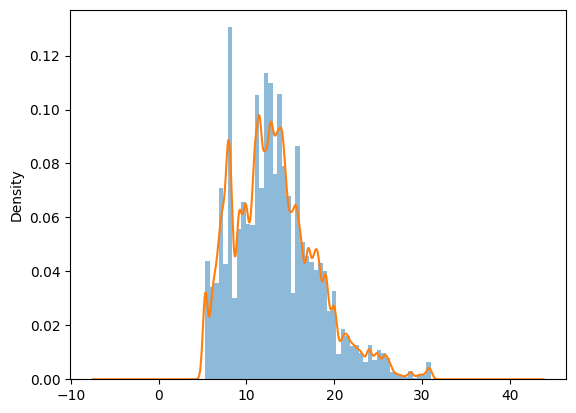

In [45]:
ax = u_data["int_rate"].plot.hist(density=True, alpha=0.5, bins=50)
u_data["int_rate"].plot.density(ax=ax);

does the distribution of loan_amnt or int_rate differ between defaulted and non-defaulted loans?

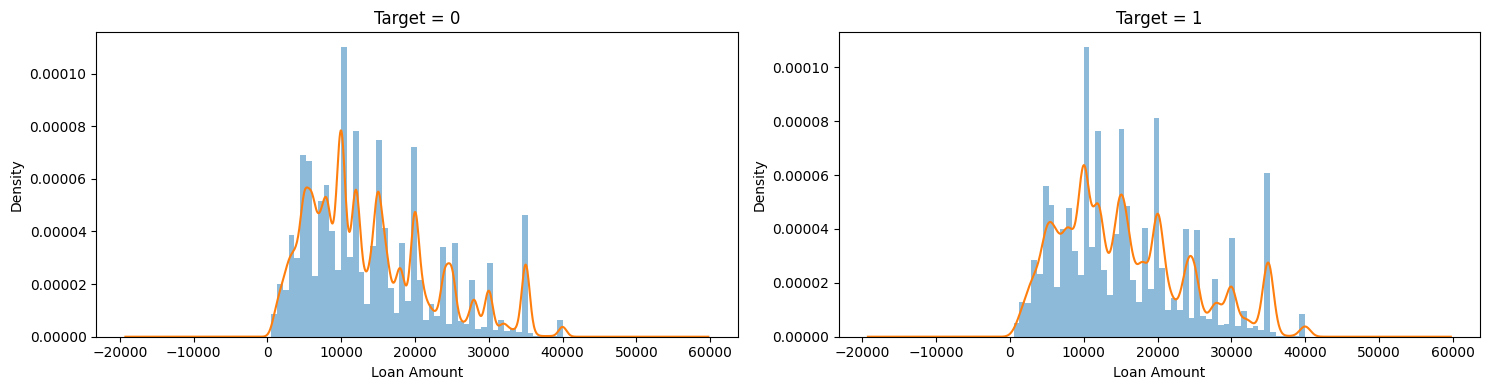

In [49]:
# loan_amnts
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 4))

# target 0
u_data[u_data["target"] == 0]["loan_amnt"].plot.hist(
    ax=ax[0],
    density=True,
    alpha=0.5,
    bins=50,
)

u_data[u_data["target"] == 0]["loan_amnt"].plot.density(
    ax=ax[0]
)

# target 1
u_data[u_data["target"] == 1]["loan_amnt"].plot.hist(
    bins=50,
    density=True,
    alpha=0.5,
    ax=ax[1]
)

u_data[u_data["target"] == 1]["loan_amnt"].plot.density(
    ax=ax[1]
)

ax[0].set_title("Target = 0")
ax[1].set_title("Target = 1")

ax[0].set_xlabel("Loan Amount")
ax[0].set_ylabel("Density")

ax[1].set_xlabel("Loan Amount")
ax[1].set_ylabel("Density")

plt.tight_layout()
plt.show()